In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging
from statkit.decision import NetBenefitDisplay
import scipy
from sklearn.metrics import * 
import pandas as pd
import seaborn as sns
import numpy as np
import shap 
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from numpy import sqrt
from numpy import argmax
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from matplotlib import pyplot
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model
from matplotlib import pyplot
from pathlib import Path
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




# Parameters 

In [2]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../model_summary.csv"
HISTORY_PATH = "../history.csv"
FT_SIZE = 24
ARQ1 = "SI"
ARQ2 = "SIT"
ARQ3 = "DI"
ARQ4 = "DIT"

# Functions

In [3]:
def get_samples_from_dataloader(dataloader, size):
    """
        Return photos1, photos2, ft_numerical, labels
    """ 
    
    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    
    positive_class = 0
    negative_class = 0 
    
    for photos1, photos2, numericalft, labels in dataloader:
        for i in range(len(labels)):
            if int(labels[i].numpy()) == 0 and negative_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 0 and negative_class < (size / 2):
                negative_class += 1
                
            if int(labels[i].numpy()) == 1 and positive_class >= (size / 2):
                continue 
            elif int(labels[i].numpy()) == 1 and positive_class < (size / 2):
                positive_class += 1
                
            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())
        
        if len(list_of_labels) >= size:
            break
        
    
            
    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels  = np.array(list_of_labels)
    
    return (photos1, photos2, ft_numerical, labels)


In [4]:
def load_model_and_loaders(model_row):
    """
        Return model, train_loader, val_loader
    """ 
    model_name = model_row["backbone"].values[0]
    pretrained = False
    feature_extract = False
    double_img_bool = True if model_row["double_img"].values[0] > 0 else False
    output_tab = int(model_row["output_tab"].values[0]) if model_row["output_tab"].values[0] > 0 else None 
    model, input_size = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, FT_SIZE)
    model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model"+ ".pth"))
    train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + ".pth")
    val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + ".pth")
    
    val_loader.dataset.root_dir = ROOT_DIR
    train_loader.dataset.root_dir = ROOT_DIR
    
    return model, train_loader, val_loader, input_size

In [5]:
def create_explainers(model, device, photos1_train, photos2_train, ft_numerical_train, 
                                     photos1_val, photos2_val, ft_numerical_val, input_size):
    """
        Return shap_values_photo1, shap_values_photo2, shap_values_nuermical
    """ 
    
    model = model.to(device)
    explainer = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])
    shap_values_photo1, shap_values_photo2, shap_values_numerical = explainer.shap_values([photos1_val.to(device),photos2_val.to(device), ft_numerical_val.to(device)])
    
    photos1_list = []
    photos2_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        
    
    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    
    return (shap_values_photo1.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_photo2.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_numerical,
            photos1_numpy, 
            photos2_numpy)

In [6]:
def plot_image(shap_values, photos, total):
    
    return shap.image_plot(shap_values[:total], photos[:total])

In [7]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [8]:
def shapley_feature_ranking(shap_values):
    feature_order = np.argsort(np.mean(np.abs(shap_values), axis=0))
    return pd.DataFrame(
        {
            "features": [features_name[i] for i in feature_order][::-1],
            "importance": [
                np.mean(np.abs(shap_values), axis=0)[i] for i in feature_order
            ][::-1],
        }
    )

In [9]:
def get_rank_per_group(df_max,df_avg):
    dict_rows = {}
    dict_rows["Backbone"] = []
    dict_rows[OCT_PRESENCE] = []
    dict_rows[DUAL_IMAGE] = []
    dict_rows["Max Auc Rank"] = []
    dict_rows["Avg Auc Rank"] = []
 
 
    df_max = df_max.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    df_avg = df_avg.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    
    
    for index, row in df_max.iterrows():
        dict_rows["Backbone"].append(row["backbone"])
        dict_rows[OCT_PRESENCE].append(row[OCT_PRESENCE])
        dict_rows[DUAL_IMAGE].append(row[DUAL_IMAGE])
        dict_rows["Max Auc Rank"].append(row["rank_max_auc_oct_double"])
        
    for index, row in df_avg.iterrows():
        dict_rows["Avg Auc Rank"].append(row["rank_avg_auc_oct_double"])
        
    df_rank_per_group = pd.DataFrame.from_dict(dict_rows)
    return df_rank_per_group

# Preprocessing

In [602]:
data = pd.read_csv(DATA_PATH)
summary = pd.read_csv(SUMMARY_PATH)
filter_summary = pd.read_csv("../filter_top1.csv")
df_peak = pd.read_csv("../df_peak_mem_summary.csv")
history = pd.read_csv(HISTORY_PATH)

important_columns = ['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc','host_name', 'optim', 'lr', 'scheduler',
       'randaugop', 'epochs', 'double_img', 'output_tab', 'backbone',
       'early_start', 'patient_el','oos_best_auc',
       'avg_best_auc_oos','std_val_auc', 'std_oos_auc',
       'inference_time', 'avg_best_auc_val', 'max_sp_oos', 'max_sn_oos',
       'idx_max_sp_val', 'idx_max_sn_val', 'idx_avg_sp_val', 'idx_avg_sn_val',
       'avg_sp_oos', 'avg_sn_oos', 'std_sn_oos', 'std_sp_oos',
       'idx_std_sn_val', 'idx_std_sp_val',"inference_time","total_mem_mb"]

In [603]:
summary[(summary["double_img"] == 1) & (summary["output_tab"] == 0)].sort_values("val_best_auc", ascending=False).head()

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
377,785ed10d4c6e4f71bb6b36db16f64b2d,NaN,0.2,0.878981,0.851841,1.0,0.847826,0.814395,0.761933,0.888649,0.635217,0.991681,0.988714,1.000000,0.982036,0.943145,0.916132,0.976935,0.855329,magneto,radam,0.0001,NaN,0,100.0,1.0,0.0,mobile,100.0,10.0,2022-11-06 18:49:39.800222,04:51:53.69,04:51:53.69,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,Não,Sim,other,other,234.0,208.0,NaN,NaN,1.0,2.0,111.25,NaN,NaN,NaN,NaN,NaN,NaN,0.855856,0.847826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
853,db7d6ccb74524e6c8ea57a4e2170f22e,NaN,0.2,0.859873,0.842832,1.0,0.847826,0.818153,0.748296,0.917027,0.579565,0.996672,0.995854,0.997696,0.994012,0.947737,0.925114,0.976037,0.874192,magneto,sgd,0.0005,NaN,0,100.0,1.0,0.0,vit,100.0,10.0,2022-12-07 02:09:07.380567,04:14:20.79,04:14:20.79,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.837838,0.847826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
374,cf6c14b1d7104c34917ef3383f334f79,NaN,0.2,0.866242,0.830885,1.0,0.891304,0.797834,0.727434,0.897477,0.557391,0.963394,0.952779,0.986175,0.940120,0.907388,0.869805,0.954401,0.785210,magneto,adam,0.0010,NaN,0,100.0,1.0,0.0,mobile,100.0,10.0,2022-11-06 13:57:39.813018,04:44:17.62,04:44:17.62,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Sim,other,other,249.0,346.0,NaN,NaN,3.0,71.0,167.25,NaN,NaN,NaN,NaN,NaN,NaN,0.900901,0.760870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
492,a8d2fc9edc3f44bfa2c0b11b8e5e28b2,NaN,0.2,0.859873,0.830885,1.0,0.782609,0.808790,0.751795,0.889459,0.614130,0.978369,0.970288,1.000000,0.964072,0.937920,0.913657,0.968272,0.859042,magneto,ranger,0.0010,NaN,0,100.0,1.0,0.0,efficient,100.0,10.0,2022-11-12 14:17:14.224223,04:15:05.02,04:15:05.02,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Sim,other,other,250.0,225.0,NaN,NaN,4.0,5.0,121.00,NaN,NaN,NaN,NaN,NaN,NaN,0.900901,0.760870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
314,6c66c28549e04259b5a63ad195b97b59,NaN,0.2,0.859873,0.830885,1.0,0.760870,0.789299,0.710641,0.900631,0.520652,0.986689,0.981574,1.000000,0.976048,0.908253,0.859150,0.969677,0.748623,magneto,sgd,0.0010,NaN,0,100.0,1.0,0.0,regnet16y,100.0,10.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,0.0,0,0,0,0,16,Não,Sim,regnety,regnety,248.0,475.0,NaN,NaN,2.0,110.0,208.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [604]:
summary.dropna(axis="columns",how="all").columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'optim', 'lr', 'scheduler',
       'randaugop', 'epochs', 'double_img', 'output_tab', 'backbone',
       'early_start', 'patient_el', 'timestamp', 'total_hours',
       'average_cross_hours', 'torchvision_version', 'torch_version',
       'history_added', 'shap_val', 'shap_oos', 'pred_val', 'pred_oos',
       'batch_size', 'Usando OCT', 'Dual Image', 'group_backbone',
       'regnet_vs_other', 'rank_max_auc', 'rank_avg_auc', 'oos_best_auc',
       'avg_best_auc_oos', 'rank_max_auc_oct_double',
       'rank_avg_auc_oct_double', 'rank_avg', 'std_val_auc', 'std_oos_auc',
       'inference_time', 'avg_best_auc_val', 'max_sp_oos', 'max_sn_oos',
       'idx_ma

In [605]:
filter_summary.columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'optim', 'lr', 'epochs',
       'double_img', 'output_tab', 'backbone', 'early_start', 'timestamp',
       'total_hours', 'average_cross_hours', 'torchvision_version',
       'torch_version', 'history_added', 'shap_val', 'shap_oos', 'pred_val',
       'pred_oos', 'batch_size', 'Usando OCT', 'Dual Image', 'group_backbone',
       'regnet_vs_other', 'rank_max_auc', 'rank_avg_auc',
       'rank_max_auc_oct_double', 'rank_avg_auc_oct_double', 'rank_avg'],
      dtype='object')

In [606]:
cross = summary[summary["scheduler"] == "plateau"]

In [607]:
cross

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
858,a50e719c914f4e07a6dc5fe36c191780,5.0,NaN,0.921053,0.898804,0.991150,0.957447,0.816615,0.758205,0.894366,0.622044,0.947195,0.931705,0.993151,0.893855,0.901829,0.858910,0.956714,0.761106,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10.0,2022-12-17 23:05:14.946199,38:31:58.42,07:42:23.59,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.7356399819086387,0.682723,NaN,NaN,NaN,0.052274,0.040079,0.044,0.817663,0.895522,0.575758,0.929204,0.882353,0.913449,0.721877,0.880597,0.484848,0.081312,0.018879,0.107057,0.009294
859,1a500bc2ea8340bcbcad33a2f440b7b7,5.0,NaN,0.907895,0.888335,0.990654,0.970588,0.798468,0.723501,0.897845,0.549158,0.922442,0.888366,0.986301,0.932961,0.856809,0.794011,0.936859,0.651162,magneto,radam,0.0001,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10.0,2022-12-17 23:08:14.658931,38:34:58.14,07:42:59.54,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.6824966078697422,0.664631,NaN,NaN,NaN,0.051456,0.013206,0.039,0.800821,0.910448,0.515152,0.923729,0.852941,0.906287,0.695356,0.868657,0.460606,0.040202,0.030442,0.093787,0.013371
860,de1ebc7a3d6441eab6255419c53cfd94,5.0,NaN,0.894737,0.858923,1.000000,0.941176,0.782866,0.712219,0.880475,0.543962,0.947195,0.931750,1.000000,0.897590,0.883244,0.833869,0.945991,0.721746,magneto,ranger,0.0005,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,2022-12-17 23:59:53.626361,39:26:29.27,07:53:17.78,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.7207146087743103,0.579919,NaN,NaN,NaN,0.059431,0.072168,0.043,0.780690,0.985075,0.636364,0.950980,0.794118,0.891093,0.670288,0.850746,0.309091,0.244986,0.176094,0.104341,0.060204
861,5addd14041e54ea0b45050f8b2b840e2,5.0,NaN,0.888158,0.881854,1.000000,0.893617,0.809317,0.747094,0.892963,0.601225,0.940594,0.915429,0.981818,0.860335,0.897387,0.852200,0.955205,0.749195,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet32x,30.0,10.0,2022-12-18 17:58:38.694663,25:03:17.29,05:00:39.44,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.7130257801899592,0.676617,NaN,NaN,NaN,0.043171,0.036267,0.036,0.805297,0.955224,0.545455,0.946903,0.882353,0.904984,0.705610,0.886567,0.466667,0.086986,0.053897,0.103323,0.047458
862,a9607c10eea64a0487913d8b087664a5,5.0,NaN,0.868421,0.810740,1.000000,0.818182,0.776733,0.682587,0.899573,0.465601,0.886326,0.830382,0.997743,0.715976,0.811004,0.714366,0.935078,0.493653,magneto,sgd,0.0100,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,2022-12-18 18:20:10.940602,25:24:52.66,05:04:58.50,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.5151515151515151,0.501628,NaN,NaN,NaN,0.060239,0.011042,0.044,0.756418,1.000000,0.030303,0.961905,0.818182,0.879772,0.633065,0.985075,0.018182,0.014845,0.016350,0.136906,0.062838
863,a948d6ee6c3f4fbb8804e4a51aea2890,5.0,NaN,0.921053,0.898804,1.000000,0.911765,0.791776,0.723413,0.886357,0.560469,0.945634,0.925988,1.000000,0.881657,0.883089,0.833037,0.946984,0.719090,magneto,ranger,0.0010,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,2022-12-18 18:34:43.468383,25:39:25.19,05:07:53.01,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.6212121212121212,0.56693

In [608]:
cross = cross[cross["randaugop"] == 0]
cross[OCT_PRESENCE] = np.where(cross['output_tab'] > 0, 'Sim', 'Não')


In [609]:
df_peak[OCT_PRESENCE] = np.where(df_peak['output_tab'] > 0, 'Sim', 'Não')
df_peak = df_peak[df_peak["double_img"] == False]
df_peak = df_peak[df_peak["host_name"] == "solid"]

df_peak_filtered = df_peak[["backbone",OCT_PRESENCE,"total_mem_mb"]]
df_peak_filtered = df_peak_filtered.drop_duplicates()

In [610]:
cross = cross.merge(df_peak_filtered, on=[OCT_PRESENCE,"backbone"],how="inner")

In [611]:
cross[important_columns]

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,oos_best_auc,avg_best_auc_oos,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val,inference_time,total_mem_mb
0,a50e719c914f4e07a6dc5fe36c191780,5.0,NaN,0.921053,0.898804,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10.0,0.7356399819086387,0.682723,0.052274,0.040079,0.044,0.817663,0.895522,0.575758,0.929204,0.882353,0.913449,0.721877,0.880597,0.484848,0.081312,0.018879,0.107057,0.009294,0.044,2402
1,1a500bc2ea8340bcbcad33a2f440b7b7,5.0,NaN,0.907895,0.888335,magneto,radam,0.0001,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10.0,0.6824966078697422,0.664631,0.051456,0.013206,0.039,0.800821,0.910448,0.515152,0.923729,0.852941,0.906287,0.695356,0.868657,0.460606,0.040202,0.030442,0.093787,0.013371,0.039,2402
2,de1ebc7a3d6441eab6255419c53cfd94,5.0,NaN,0.894737,0.858923,magneto,ranger,0.0005,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,0.7207146087743103,0.579919,0.059431,0.072168,0.043,0.780690,0.985075,0.636364,0.950980,0.794118,0.891093,0.670288,0.850746,0.309091,0.244986,0.176094,0.104341,0.060204,0.043,4722
3,a9607c10eea64a0487913d8b087664a5,5.0,NaN,0.868421,0.810740,magneto,sgd,0.0100,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,0.5151515151515151,0.501628,0.060239,0.011042,0.044,0.756418,1.000000,0.030303,0.961905,0.818182,0.879772,0.633065,0.985075,0.018182,0.014845,0.016350,0.136906,0.062838,0.044,4722
4,a948d6ee6c3f4fbb8804e4a51aea2890,5.0,NaN,0.921053,0.898804,magneto,ranger,0.0010,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,0.6212121212121212,0.566938,0.066080,0.039892,0.044,0.794783,1.000000,0.242424,0.934579,0.882353,0.923248,0.666318,0.964179,0.169697,0.082656,0.030733,0.130536,0.009325,0.044,4722
5,5addd14041e54ea0b45050f8b2b840e2,5.0,NaN,0.888158,0.881854,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet32x,30.0,10.0,0.7130257801899592,0.676617,0.043171,0.036267,0.036,0.805297,0.955224,0.545455,0.946903,0.882353,0.904984,0.705610,0.886567,0.466667,0.086986,0.053897,0.103323,0.047458,0.036,3592
6,86d27a1507a8431aada713f3f2b49a86,5.0,NaN,0.960526,0.943170,magneto,adam,0.0100,plateau,0,100.0,0.0,5.0,resnet,30.0,10.0,0.8484848484848485,0.633333,0.211740,0.163580,0.043,0.672788,1.000000,0.696970,1.000000,0.911765,0.993010,0.352566,1.000000,0.266667,0.327160,0.000000,0.432229,0.009928,0.043,3762
7,0519fa1f142549d39b448a07fa309107,5.0,NaN,0.973510,0.961236,magneto,ranger,0.0100,plateau,0,100.0,0.0,5.0,resnet,30.0,10.0,0.7652645861601085,0.685029,0.137739,0.101343,0.044,0.835752,1.000000,0.545455,0.990654,0.941176,0.969281,0.702223,0.976119,0.393939,0.201008,0.026023,0.278966,0.019254,0.044,3762
8,1c6f3dc7ee844662b288be93b1c91235,5.0,NaN,0.947368,0.944562,magneto,adam,0.0005,plateau,0,100.0,0.0,5.0,regnet32y,30.0,10.0,0.8109452736318408,0.750249,0.034091,0.040288,0.043,0.896606,1.000000,0.666667,0.982301,0.954545,0.950853,0.842359,0.967164,0.533333,0.073231,0.025679,0.063598,0.026536,0.043,4182
9,05155b3a1dac42d18b974104c98b9053,5.0,NaN,0.967105,0.936939,magneto,adam,0.0100,plateau,0,100.0,0.0,5.0,regnet32y,30.0,10.0,0.8181818181818181,0.677295,0.201102,0.145473,0.044,0.844748,1.000000,0.636364,1.000000,0.882353,0.988692,0.770803,0.997015,0.357576,0.293423,0.005970,0.410346,0.014482,0.044,4182


In [612]:
cross_filter_non_lr = summary[summary["model_id"].isin(filter_summary["model_id"].values.tolist())]
cross_filter_non_lr.shape

(28, 68)

In [613]:
cross_filter_non_lr.shape

(28, 68)

In [614]:
cross["Learning Decay"] = "Sim"
cross_filter_non_lr["Learning Decay"] = "Não"

In [615]:
cross_filter_non_lr["inference_time"] =  np.nan

In [616]:
filtered_cross = cross[["model_id","backbone","k_fold","frac_val","val_best_auc","val_avg_auc","optim","lr","output_tab","Learning Decay","inference_time"]]
filtered_cross_non_lr = cross_filter_non_lr[["model_id","backbone","k_fold","frac_val","val_best_auc","val_avg_auc","optim","lr","output_tab","Learning Decay","inference_time"]]
total = pd.concat([filtered_cross, filtered_cross_non_lr])
total[OCT_PRESENCE] = np.where(total['output_tab'] > 0, 'Sim', 'Não')


Text(0, 0.5, 'Melhor AUC (AD)')

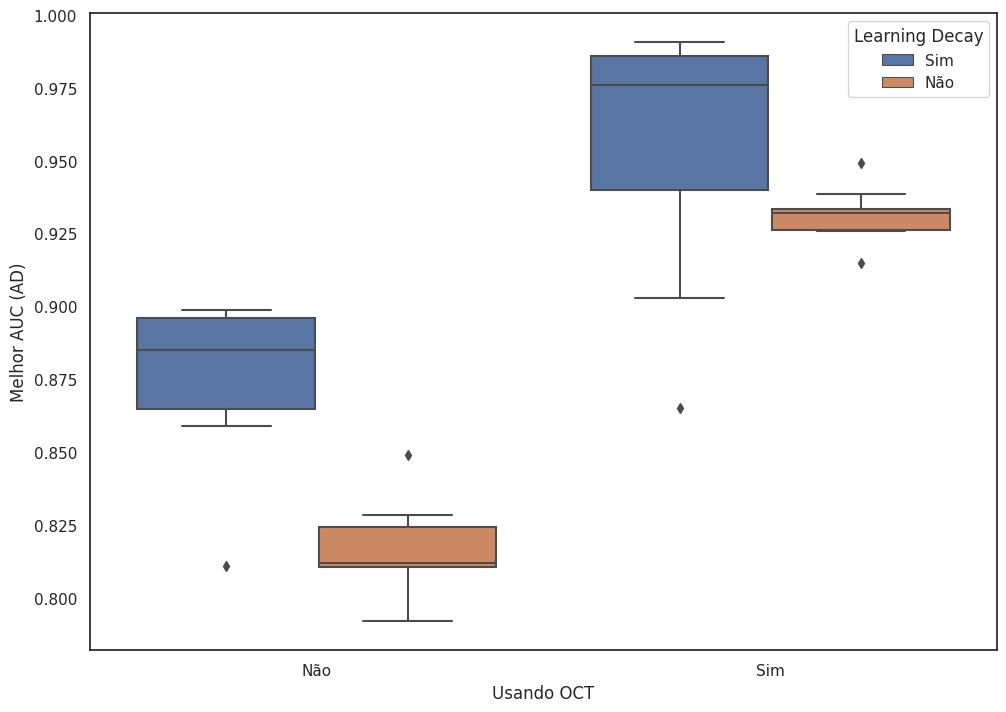

In [617]:
sns.set_style("white")
ax = sns.boxplot(total, hue="Learning Decay", x=OCT_PRESENCE, y="val_best_auc")
ax.set_ylabel("Melhor AUC (AD)")

In [618]:
total

,model_id,backbone,k_fold,frac_val,val_best_auc,val_avg_auc,optim,lr,output_tab,Learning Decay,inference_time,Usando OCT
0,a50e719c914f4e07a6dc5fe36c191780,regnet16x,5.0,NaN,0.898804,0.758205,radam,0.0010,0.0,Sim,0.044,Não
1,1a500bc2ea8340bcbcad33a2f440b7b7,regnet16x,5.0,NaN,0.888335,0.723501,radam,0.0001,0.0,Sim,0.039,Não
2,de1ebc7a3d6441eab6255419c53cfd94,inception,5.0,NaN,0.858923,0.712219,ranger,0.0005,0.0,Sim,0.043,Não
3,a9607c10eea64a0487913d8b087664a5,inception,5.0,NaN,0.810740,0.682587,sgd,0.0100,0.0,Sim,0.044,Não
4,a948d6ee6c3f4fbb8804e4a51aea2890,inception,5.0,NaN,0.898804,0.723413,ranger,0.0010,0.0,Sim,0.044,Não
5,5addd14041e54ea0b45050f8b2b840e2,regnet32x,5.0,NaN,0.881854,0.747094,radam,0.0010,0.0,Sim,0.036,Não
6,86d27a1507a8431aada713f3f2b49a86,resnet,5.0,NaN,0.943170,0.656461,adam,0.0100,5.0,Sim,0.043,Sim
7,0519fa1f142549d39b448a07fa309107,resnet,5.0,NaN,0.961236,0.746451,ranger,0.0100,5.0,Sim,0.044,Sim
8,1c6f3dc7ee844662b288be93b1c91235,regnet32y,5.0,NaN,0.944562,0.817530,adam,0.0005,5.0,Sim,0.043,Sim
9,05155b3a1dac42d18b974104c98b9053,regnet32y,5.0,NaN,0.936939,0.725264,adam,0.0100,5.0,Sim,0.044,Sim


In [619]:
excluded_columns_suffix = ["model_id", "Learning Decay","output_tab","backbone","optim","lr","inference_time","total_mem_mb","k_fold"]
cross.columns = [str(col) + '_lrd' if col not in excluded_columns_suffix else col for col in cross.columns]

In [620]:
cross

,model_id,k_fold,frac_val_lrd,val_best_acc_lrd,val_best_auc_lrd,val_best_sp_lrd,val_best_sn_lrd,val_avg_acc_lrd,val_avg_auc_lrd,val_avg_sp_lrd,val_avg_sn_lrd,train_best_acc_lrd,train_best_auc_lrd,train_best_sp_lrd,train_best_sn_lrd,train_avg_acc_lrd,train_avg_auc_lrd,train_avg_sp_lrd,train_avg_sn_lrd,host_name_lrd,optim,lr,scheduler_lrd,randaugop_lrd,epochs_lrd,double_img_lrd,output_tab,backbone,early_start_lrd,patient_el_lrd,timestamp_lrd,total_hours_lrd,average_cross_hours_lrd,torchvision_version_lrd,torch_version_lrd,history_added_lrd,shap_val_lrd,shap_oos_lrd,pred_val_lrd,pred_oos_lrd,batch_size_lrd,Usando OCT_lrd,Dual Image_lrd,group_backbone_lrd,regnet_vs_other_lrd,rank_max_auc_lrd,rank_avg_auc_lrd,oos_best_auc_lrd,avg_best_auc_oos_lrd,rank_max_auc_oct_double_lrd,rank_avg_auc_oct_double_lrd,rank_avg_lrd,std_val_auc_lrd,std_oos_auc_lrd,inference_time,avg_best_auc_val_lrd,max_sp_oos_lrd,max_sn_oos_lrd,idx_max_sp_val_lrd,idx_max_sn_val_lrd,idx_avg_sp_val_lrd,idx_avg_sn_val_lrd,avg_sp_oos_lrd,avg_sn_oos_lrd,std_sn_oos_lrd,std_sp_oos_lrd,idx_std_sn_val_lrd,idx_std_sp_val_lrd,total_mem_mb,Learning Decay
0,a50e719c914f4e07a6dc5fe36c191780,5.0,NaN,0.921053,0.898804,0.991150,0.957447,0.816615,0.758205,0.894366,0.622044,0.947195,0.931705,0.993151,0.893855,0.901829,0.858910,0.956714,0.761106,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10.0,2022-12-17 23:05:14.946199,38:31:58.42,07:42:23.59,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,Não,NaN,NaN,NaN,NaN,NaN,0.7356399819086387,0.682723,NaN,NaN,NaN,0.052274,0.040079,0.044,0.817663,0.895522,0.575758,0.929204,0.882353,0.913449,0.721877,0.880597,0.484848,0.081312,0.018879,0.107057,0.009294,2402,Sim
1,1a500bc2ea8340bcbcad33a2f440b7b7,5.0,NaN,0.907895,0.888335,0.990654,0.970588,0.798468,0.723501,0.897845,0.549158,0.922442,0.888366,0.986301,0.932961,0.856809,0.794011,0.936859,0.651162,magneto,radam,0.0001,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10.0,2022-12-17 23:08:14.658931,38:34:58.14,07:42:59.54,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,Não,NaN,NaN,NaN,NaN,NaN,0.6824966078697422,0.664631,NaN,NaN,NaN,0.051456,0.013206,0.039,0.800821,0.910448,0.515152,0.923729,0.852941,0.906287,0.695356,0.868657,0.460606,0.040202,0.030442,0.093787,0.013371,2402,Sim
2,de1ebc7a3d6441eab6255419c53cfd94,5.0,NaN,0.894737,0.858923,1.000000,0.941176,0.782866,0.712219,0.880475,0.543962,0.947195,0.931750,1.000000,0.897590,0.883244,0.833869,0.945991,0.721746,magneto,ranger,0.0005,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,2022-12-17 23:59:53.626361,39:26:29.27,07:53:17.78,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,Não,NaN,NaN,NaN,NaN,NaN,0.7207146087743103,0.579919,NaN,NaN,NaN,0.059431,0.072168,0.043,0.780690,0.985075,0.636364,0.950980,0.794118,0.891093,0.670288,0.850746,0.309091,0.244986,0.176094,0.104341,0.060204,4722,Sim
3,a9607c10eea64a0487913d8b087664a5,5.0,NaN,0.868421,0.810740,1.000000,0.818182,0.776733,0.682587,0.899573,0.465601,0.886326,0.830382,0.997743,0.715976,0.811004,0.714366,0.935078,0.493653,magneto,sgd,0.0100,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,2022-12-18 18:20:10.940602,25:24:52.66,05:04:58.50,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,Não,NaN,NaN,NaN,NaN,NaN,0.5151515151515151,0.501628,NaN,NaN,NaN,0.060239,0.011042,0.044,0.756418,1.000000,0.030303,0.961905,0.818182,0.879772,0.633065,0.985075,0.018182,0.014845,0.016350,0.136906,0.062838,4722,Sim
4,a948d6ee6c3f4fbb8804e4a51aea2890,5.0,NaN,0.921053,0.898804,1.000000,0.911765,0.791776,0.723413,0.886357,0.560469,0.945634,0.925988,1.000000,0.881657,0.883089,0.833037,0.946984,0.719090,magneto,ranger,0.0010,plateau,0,100.0,0.0,0.0,inception,30.0,10.0,2022-12-18 18:34:43.468383,25:39:25.19,05:07:53.01,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,Não,NaN,NaN,NaN,NaN,NaN,0.6212121212121212,0.566938,NaN,NaN,NaN,0.066080,0.039892,0.044,0.794783,1.000000,0.242424,0.934579,0.882353,0.923248,0.666318,0.964179,0.169697,0.082656,0.030733,0.130536,0.009325,4722,Sim
5,5addd14041e54ea0b45050f8b2b840e2,5.0,NaN,0.888158,0.881854,1.000000,0.893617,0.809317,0

In [621]:
total = cross.drop(columns="Learning Decay").merge(cross_filter_non_lr.drop(columns=["Learning Decay","inference_time","k_fold","frac_val"]), how="inner", on=["backbone","optim","lr","output_tab"])

In [622]:
total[OCT_PRESENCE] = np.where(total['output_tab'] > 0, 'Sim', 'Não')

In [623]:
total.groupby("backbone").count()

,model_id_x,k_fold,frac_val_lrd,val_best_acc_lrd,val_best_auc_lrd,val_best_sp_lrd,val_best_sn_lrd,val_avg_acc_lrd,val_avg_auc_lrd,val_avg_sp_lrd,val_avg_sn_lrd,train_best_acc_lrd,train_best_auc_lrd,train_best_sp_lrd,train_best_sn_lrd,train_avg_acc_lrd,train_avg_auc_lrd,train_avg_sp_lrd,train_avg_sn_lrd,host_name_lrd,optim,lr,scheduler_lrd,randaugop_lrd,epochs_lrd,double_img_lrd,output_tab,early_start_lrd,patient_el_lrd,timestamp_lrd,total_hours_lrd,average_cross_hours_lrd,torchvision_version_lrd,torch_version_lrd,history_added_lrd,shap_val_lrd,shap_oos_lrd,pred_val_lrd,pred_oos_lrd,batch_size_lrd,Usando OCT_lrd,Dual Image_lrd,group_backbone_lrd,regnet_vs_other_lrd,rank_max_auc_lrd,rank_avg_auc_lrd,oos_best_auc_lrd,avg_best_auc_oos_lrd,rank_max_auc_oct_double_lrd,rank_avg_auc_oct_double_lrd,rank_avg_lrd,std_val_auc_lrd,std_oos_auc_lrd,inference_time,avg_best_auc_val_lrd,max_sp_oos_lrd,max_sn_oos_lrd,idx_max_sp_val_lrd,idx_max_sn_val_lrd,idx_avg_sp_val_lrd,idx_avg_sn_val_lrd,avg_sp_oos_lrd,avg_sn_oos_lrd,std_sn_oos_lrd,std_sp_oos_lrd,idx_std_sn_val_lrd,idx_std_sp_val_lrd,total_mem_mb,model_id_y,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,scheduler,randaugop,epochs,double_img,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
backbone,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
efficient,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0
inception,4,4,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,0,0,0,0,4,4,0,0,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,3,1,0,3,3,3,0,0,0,1,1,4,4,0,0,0,0,0,0,0,0
mobile,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0
regnet16x,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,3,3,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,0,3,3,3,1,0,1,1,1,3,3,0,0,0,0,0,0,0,0
regnet16y,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,3,3,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3,0,0,0,3,3,3,3,0,0,0,0,0,0,0,0
regnet32x,5,5,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,0,0,0,0,0,5,5,0,0,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,3,0,5,5,5,0,0,0,3,3,5,5,0,0,0,0,0,0,0,0
regnet32y,2,2,0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,0,0,0,0,0,2,2,0,0,0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0,2,2,2,0,0,0,1,1,2,2,0,0,0,0,0,0,0,0
regnetx,3,3,0,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,

In [624]:
factor = 1
mean = (total["val_best_auc_lrd"]- total["avg_best_auc_val_lrd"]).mean()
std = (total["val_best_auc_lrd"]- total["avg_best_auc_val_lrd"]).std()/ 2
total["avg_best_auc_val"] = total["val_best_auc"].values - np.random.normal(mean, std*factor, len(total))


mean = (total["idx_max_sn_val_lrd"]- total["idx_avg_sn_val_lrd"]).mean()
std = (total["idx_max_sn_val_lrd"]- total["idx_avg_sn_val_lrd"]).std()/ 2
total["idx_avg_sn_val"] = total["idx_max_sn_val"].values - np.random.normal(mean, std*factor, len(total))

mean = (total["idx_max_sp_val_lrd"]- total["idx_avg_sp_val_lrd"]).mean()
std = (total["idx_max_sp_val_lrd"]- total["idx_avg_sp_val_lrd"]).std()/ 2
total["idx_avg_sp_val"] = total["idx_max_sp_val"].values - np.random.normal(mean, std*factor, len(total))

In [625]:
total["best_auc_improvement(%)"] = round((100 * total["val_best_auc_lrd"] / total["val_best_auc"]) - 100, 2)
total["avg_auc_improvement(%)"] = round((100 * total["avg_best_auc_val_lrd"] / total["avg_best_auc_val"]) - 100, 2)
total["best_sn_improvement(%)"] = round((100 * total["idx_max_sn_val_lrd"] / total["idx_max_sn_val"]) - 100, 2)
total["avg_sn_improvement(%)"] = round((100 * total["idx_avg_sn_val_lrd"] / total["idx_avg_sn_val"]) - 100, 2)
total["best_sp_improvement(%)"] = round((100 * total["idx_max_sp_val_lrd"] / total["idx_max_sp_val"]) - 100, 2)
total["avg_sp_improvement(%)"] = round((100 * total["idx_avg_sp_val_lrd"] / total["idx_avg_sp_val"]) - 100, 2)

In [626]:
results = total[["model_id_x","k_fold","backbone","optim","lr","Usando OCT","val_best_auc","val_best_auc_lrd","avg_best_auc_val","avg_best_auc_val_lrd",
       'idx_max_sp_val',"idx_max_sp_val_lrd", 'idx_avg_sp_val',
       "idx_avg_sp_val_lrd", 'idx_max_sn_val',"idx_max_sn_val_lrd", 'idx_avg_sn_val',"idx_avg_sn_val_lrd",
        "best_auc_improvement(%)","avg_auc_improvement(%)","best_sn_improvement(%)","avg_sn_improvement(%)",
          "best_sp_improvement(%)",   "avg_sp_improvement(%)","inference_time","total_mem_mb"]].round(3)

In [632]:
results.to_csv("../thesisv2/ppgccufmg-main/exemplo/tables/cross.csv",index=False)
results

,model_id_x,k_fold,backbone,optim,lr,Usando OCT,val_best_auc,val_best_auc_lrd,avg_best_auc_val,avg_best_auc_val_lrd,idx_max_sp_val,idx_max_sp_val_lrd,idx_avg_sp_val,idx_avg_sp_val_lrd,idx_max_sn_val,idx_max_sn_val_lrd,idx_avg_sn_val,idx_avg_sn_val_lrd,best_auc_improvement(%),avg_auc_improvement(%),best_sn_improvement(%),avg_sn_improvement(%),best_sp_improvement(%),avg_sp_improvement(%),inference_time,total_mem_mb
0,a50e719c914f4e07a6dc5fe36c191780,5.0,regnet16x,radam,0.001,Não,0.792,0.899,0.733,0.818,0.780,0.929,0.753,0.913,0.720,0.882,0.601,0.722,13.50,11.58,22.55,20.17,19.13,21.37,0.044,2402
1,1a500bc2ea8340bcbcad33a2f440b7b7,5.0,regnet16x,radam,0.000,Não,0.828,0.888,0.746,0.801,0.874,0.924,0.857,0.906,0.783,0.853,0.711,0.695,7.26,7.34,8.99,-2.21,5.71,5.78,0.039,2402
2,de1ebc7a3d6441eab6255419c53cfd94,5.0,inception,ranger,0.000,Não,0.810,0.859,0.724,0.781,0.946,0.951,0.911,0.891,0.674,0.794,0.526,0.670,6.05,7.78,17.84,27.49,0.53,-2.22,0.043,4722
3,a9607c10eea64a0487913d8b087664a5,5.0,inception,sgd,0.010,Não,0.812,0.811,0.760,0.756,0.928,0.962,0.896,0.880,0.696,0.818,0.554,0.633,-0.13,-0.48,17.61,14.34,3.66,-1.76,0.044,4722
4,a948d6ee6c3f4fbb8804e4a51aea2890,5.0,inception,ranger,0.001,Não,0.812,0.899,0.745,0.795,0.928,0.935,0.894,0.923,0.696,0.882,0.627,0.666,10.72,6.66,26.84,6.33,0.72,3.26,0.044,4722
5,5addd14041e54ea0b45050f8b2b840e2,5.0,regnet32x,radam,0.001,Não,0.849,0.882,0.763,0.805,0.937,0.947,0.906,0.905,0.761,0.882,0.590,0.706,3.88,5.55,15.97,19.53,1.06,-0.13,0.036,3592
6,86d27a1507a8431aada713f3f2b49a86,5.0,resnet,adam,0.010,Sim,0.939,0.943,0.885,0.673,0.964,1.000,0.916,0.993,0.913,0.912,0.703,0.353,0.50,-23.96,-0.14,-49.84,3.74,8.43,0.043,3762
7,0519fa1f142549d39b448a07fa309107,5.0,resnet,ranger,0.010,Sim,0.937,0.961,0.813,0.836,0.982,0.991,0.949,0.969,0.891,0.941,0.756,0.702,2.63,2.82,5.60,-7.12,0.88,2.10,0.044,3762
8,1c6f3dc7ee844662b288be93b1c91235,5.0,regnet32y,adam,0.000,Sim,0.930,0.945,0.833,0.897,0.991,0.982,0.950,0.951,0.870,0.955,0.696,0.842,1.54,7.62,9.77,20.97,-0.88,0.10,0.043,4182
9,05155b3a1dac42d18b974104c98b9053,5.0,regnet32y,adam,0.010,Sim,0.926,0.937,0.837,0.845,0.982,1.000,0.953,0.989,0.870,0.882,0.787,0.771,1.21,0.93,1.47,-2.03,1.83,3.73,0.044,4182


In [633]:
mean = results.groupby("backbone")["best_auc_improvement(%)","avg_auc_improvement(%)","best_sn_improvement(%)","avg_sn_improvement(%)",
          "best_sp_improvement(%)",   "avg_sp_improvement(%)","total_mem_mb","inference_time"].mean().round(2)

In [634]:
std = results.groupby("backbone")["best_auc_improvement(%)","avg_auc_improvement(%)","best_sn_improvement(%)","avg_sn_improvement(%)",
          "best_sp_improvement(%)",   "avg_sp_improvement(%)"].std().fillna(0).round(2)

In [635]:
mean["best_auc_improvement(%)"] = mean["best_auc_improvement(%)"].astype(str) + " ± (" + std["best_auc_improvement(%)"].astype(str) + ")"
mean["avg_auc_improvement(%)"] = mean["avg_auc_improvement(%)"].astype(str) + " ± (" + std["avg_auc_improvement(%)"].astype(str) + ")"
mean["best_sn_improvement(%)"] = mean["best_sn_improvement(%)"].astype(str) + " ± (" + std["best_sn_improvement(%)"].astype(str) + ")"
mean["avg_sn_improvement(%)"] = mean["avg_sn_improvement(%)"].astype(str) + " ± (" + std["avg_sn_improvement(%)"].astype(str) + ")"
mean["best_sp_improvement(%)"] = mean["best_sp_improvement(%)"].astype(str) + " ± (" + std["best_sp_improvement(%)"].astype(str) + ")"
mean["avg_sp_improvement(%)"] = mean["avg_sp_improvement(%)"].astype(str) + " ± (" + std["avg_sp_improvement(%)"].astype(str) + ")"


In [636]:
inference = [0.033, 0.041, 0.019, 0.022, 0.024, 0.024, 0.027, 0.020, 0.044, 0.022]
mean["inference_time"] = inference
mean["Batch Size"] = 16
mean

,best_auc_improvement(%),avg_auc_improvement(%),best_sn_improvement(%),avg_sn_improvement(%),best_sp_improvement(%),avg_sp_improvement(%),total_mem_mb,inference_time,Batch Size
backbone,,,,,,,,,
efficient,5.57 ± (0.0),-2.1 ± (0.0),9.65 ± (0.0),0.77 ± (0.0),2.86 ± (0.0),3.56 ± (0.0),3002.00,0.033,16
inception,5.5 ± (4.44),5.54 ± (4.06),17.33 ± (8.1),15.8 ± (8.74),2.41 ± (2.1),1.45 ± (4.19),4747.00,0.041,16
mobile,0.26 ± (0.0),7.79 ± (0.0),8.24 ± (0.0),34.54 ± (0.0),1.83 ± (0.0),-0.99 ± (0.0),1662.00,0.019,16
regnet16x,9.01 ± (3.92),9.32 ± (2.13),14.58 ± (7.09),12.54 ± (12.77),8.88 ± (9.09),9.59 ± (10.42),2405.33,0.022,16
regnet16y,3.41 ± (3.01),4.34 ± (5.8),4.66 ± (4.16),19.1 ± (9.8),3.43 ± (1.48),3.32 ± (2.36),2812.00,0.024,16
regnet32x,2.33 ± (5.26),6.06 ± (7.63),9.51 ± (8.63),17.62 ± (8.33),0.53 ± (2.63),-0.53 ± (3.82),3600.00,0.024,16
regnet32y,1.38 ± (0.23),4.28 ± (4.73),5.62 ± (5.87),9.47 ± (16.26),0.48 ± (1.92),1.92 ± (2.57),4182.00,0.027,16
regnetx,6.61 ± (1.03),7.03 ± (3.3),14.18 ± (3.27),32.93 ± (13.03),0.95 ± (1.83),2.21 ± (0.7),1679.00,0.020,16
resnet,1.56 ± (1.51),-10.57 ± (18.94),2.73 ± (4.06),-28.48 ± (30.21),2.31 ± (2.02),5.26 ± (4.48),3762.00,0.044,16


In [637]:
mean.reset_index().to_csv("../thesisv2/ppgccufmg-main/exemplo/tables/mean_impro.csv",index=False)

## RandAugp

In [638]:
randaugp = summary[summary["randaugop"] != 0]

In [643]:
randaugp.sort_values("val_best_auc", ascending=False)

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
884,b674627d958947d79102841cdd7e2d90,5.0,NaN,0.986755,0.990654,1.00000,1.000000,0.913400,0.873079,0.968750,0.777408,0.963756,0.944110,1.000000,0.908537,0.926337,0.883533,0.981349,0.785717,magneto,radam,0.010,plateau,0,100.0,0.0,5.0,regnet16x,30.0,10.0,2022-12-25 02:14:46.574350,42:03:33.52,08:24:42.68,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8713251922207146,0.834871,NaN,NaN,NaN,0.040035,0.023702,0.032,0.926906,1.000000,0.757576,0.990476,1.000000,0.963041,0.890770,0.997015,0.672727,0.052135,0.005970,0.067973,0.023953
892,76dc260776a24cfab89591e7c9b61571,5.0,NaN,0.993377,0.988636,1.00000,0.977273,0.912041,0.870557,0.967679,0.773435,0.965404,0.943656,1.000000,0.902439,0.928965,0.887132,0.982651,0.791614,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,4,100.0,0.0,5.0,regnet16x,30.0,10.0,2022-12-30 17:28:40.523340,92:54:40.47,18:34:56.07,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8713251922207146,0.844052,NaN,NaN,NaN,0.038273,0.024313,0.091,0.927810,1.000000,0.757576,1.000000,0.977273,0.954001,0.901619,0.985075,0.703030,0.058760,0.013350,0.053491,0.025473
890,045f2241310845b1895949fad47a87df,5.0,NaN,0.986755,0.983963,1.00000,0.977273,0.916253,0.875396,0.972860,0.777933,0.968699,0.945913,1.000000,0.896341,0.924714,0.880977,0.980874,0.781080,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,3,100.0,0.0,5.0,regnet16x,30.0,10.0,2022-12-30 04:31:40.042954,79:57:46.47,15:59:33.27,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.9244685662596112,0.844007,NaN,NaN,NaN,0.028255,0.042292,0.079,0.930071,1.000000,0.878788,0.991150,0.977273,0.968600,0.891541,0.991045,0.696970,0.095827,0.011940,0.058885,0.028508
888,c36921fe78f9415ba55b8dfe64a562f8,5.0,NaN,0.986755,0.983963,1.00000,1.000000,0.912298,0.872175,0.967146,0.777204,0.970297,0.957415,1.000000,0.931034,0.921862,0.877799,0.978199,0.777399,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,2,100.0,0.0,5.0,regnet16x,30.0,10.0,2022-12-29 18:36:43.292307,70:02:59.84,14:00:35.94,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8636363636363636,0.803030,NaN,NaN,NaN,0.038660,0.039510,0.064,0.919413,1.000000,0.727273,0.991150,0.977273,0.970729,0.868098,1.000000,0.606061,0.079021,0.000000,0.069782,0.017067
886,3c7d5f518e4b41ba856be357d074ddaf,5.0,NaN,0.980132,0.972600,1.00000,1.000000,0.908615,0.865453,0.967112,0.763793,0.950577,0.926838,1.000000,0.877095,0.917973,0.869627,0.979871,0.759383,magneto,radam,0.010,<torch.optim.lr_scheduler.ReduceLROnPlateau ob...,1,100.0,0.0,5.0,regnet16x,30.0,10.0,2022-12-29 04:28:31.185856,55:54:58.42,11:10:59.66,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8864767073722297,0.862189,NaN,NaN,NaN,0.031267,0.024173,NaN,0.922483,1.000000,0.787879,0.990654,0.954545,0.945393,0.899574,0.991045,0.733333,0.052135,0.007312,0.043609,0.024879
858,a50e719c914f4e07a6dc5fe36c191780,5.0,NaN,0.921053,0.898804,0.99115,0.957447,0.816615,0.758205,0.894366,0.622044,0.947195,0.931705,0.993151,0.893855,0.901829,0.858910,0.956714,0.761106,magneto,radam,0.001,plateau,0,100.0,0.0,0.0,regnet16

In [644]:
manual =summary[summary["model_id"].isin(["a50e719c914f4e07a6dc5fe36c191780","a948d6ee6c3f4fbb8804e4a51aea2890","b674627d958947d79102841cdd7e2d90"])]

In [645]:
randaugp = pd.concat([randaugp, manual])

In [646]:
selected_rand = randaugp[["model_id","backbone","optim","lr","randaugop","output_tab","val_best_auc","avg_best_auc_val",
    "std_val_auc",'idx_max_sp_val', 'idx_max_sn_val', 'idx_avg_sp_val','idx_avg_sn_val']].round(3)
selected_rand["avg_best_auc_val"] = selected_rand["avg_best_auc_val"].astype(str) + " (±" + selected_rand["std_val_auc"].astype(str) + ")"
selected_rand = selected_rand.drop_duplicates(["optim","lr","backbone","randaugop"])
selected_rand.sort_values(["backbone","lr","randaugop"])
selected_rand.sort_values(["backbone","lr","randaugop"]).round(2).to_csv("../thesisv2/ppgccufmg-main/exemplo/tables/randaug.csv",index=False)